In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set(style='whitegrid')


In [47]:
import pandas as pd

# Load datasets separately 
bio = pd.read_csv("biometric.csv")
demo = pd.read_csv("demographic.csv")
enr = pd.read_csv("enrolment.csv")

# Preview each dataset 
print("Biometric Data:")
print(biometric.head())

print("\nDemographic Data:")
print(demo.head())

print("\nEnrolment Data:")
print(enr.head())

Biometric Data:
        date              state      district  pincode  bio_age_5_17  \
0 2025-03-01            Haryana  Mahendragarh   123029           280   
1 2025-03-01              Bihar     Madhepura   852121           144   
2 2025-03-01  Jammu and Kashmir         Punch   185101           643   
3 2025-03-01              Bihar       Bhojpur   802158           256   
4 2025-03-01         Tamil Nadu       Madurai   625514           271   

   bio_age_17_  
0          577  
1          369  
2         1091  
3          980  
4          815  

Demographic Data:
         date           state    district  pincode  demo_age_5_17  \
0  01-03-2025   Uttar Pradesh   Gorakhpur   273213             49   
1  01-03-2025  Andhra Pradesh    Chittoor   517132             22   
2  01-03-2025         Gujarat      Rajkot   360006             65   
3  01-03-2025  Andhra Pradesh  Srikakulam   532484             24   
4  01-03-2025       Rajasthan     Udaipur   313801             45   

   demo_age_17_

In [ ]:
# Convert date for all datasets
for dataset in [bio, demo, enr]:
    dataset['date'] = pd.to_datetime(dataset['date'], dayfirst=True)

In [11]:
print("\nMissing Values - Biometric:")
print(bio.isnull().sum())

print("\nMissing Values - Demographic:")
print(demo.isnull().sum())

print("\nMissing Values - Enrolment:")
print(enr.isnull().sum())


Missing Values - Biometric:
date            0
state           0
district        0
pincode         0
bio_age_5_17    0
bio_age_17_     0
dtype: int64

Missing Values - Demographic:
date             0
state            0
district         0
pincode          0
demo_age_5_17    0
demo_age_17_     0
dtype: int64

Missing Values - Enrolment:
date              0
state             0
district          0
pincode           0
age_0_5           0
age_5_17          0
age_18_greater    0
dtype: int64


In [19]:

print(bio.columns)
print(demo.columns)
print(enr.columns)

Index(['date', 'state', 'district', 'pincode', 'bio_age_5_17', 'bio_age_17_'], dtype='object')
Index(['date', 'state', 'district', 'pincode', 'demo_age_5_17',
       'demo_age_17_'],
      dtype='object')
Index(['date', 'state', 'district', 'pincode', 'age_0_5', 'age_5_17',
       'age_18_greater'],
      dtype='object')


In [43]:
# Clean column names
for df_ in [bio, demo, enr]:
    df_.columns = df_.columns.str.strip().str.lower()

In [49]:
# Standardize column names
for df_ in [bio, demo, enr]:
    df_.columns = df_.columns.str.strip().str.lower()

# Rename bio columns with correct, unambiguous prefixes
bio = bio.rename(columns={
    'age_5_17':       'bio_age_5_17',
    'age_18_greater': 'bio_age_18_greater'   # FIXED: was 'bio_age_17'
})

# Rename demo columns
demo = demo.rename(columns={
    'age_5_17':       'demo_age_5_17',
    'age_18_greater': 'demo_age_18_greater'  # FIXED: was 'demo_age_17'
})

# enr retains its original column names: age_0_5, age_5_17, age_18_greater

# Merge on common keys
df = bio.merge(demo, on=['date', 'state', 'district', 'pincode'], how='outer')
df = df.merge(enr,  on=['date', 'state', 'district', 'pincode'], how='outer')

# Fill numeric NaNs with 0
num_cols = df.select_dtypes(include='number').columns
df[num_cols] = df[num_cols].fillna(0)

df.head()

,date,state,district,pincode,bio_age_5_17,bio_age_17_,demo_age_5_17,demo_age_17_,age_0_5,age_5_17,age_18_greater
0,01-03-2025,Andaman & Nicobar Islands,Andamans,744101,16.0,193.0,0.0,0.0,0.0,0.0,0.0
1,01-03-2025,Andaman and Nicobar Islands,Nicobar,744301,101.0,48.0,16.0,180.0,0.0,0.0,0.0
2,01-03-2025,Andaman and Nicobar Islands,Nicobar,744301,101.0,48.0,16.0,180.0,0.0,0.0,0.0
3,01-03-2025,Andaman and Nicobar Islands,Nicobar,744302,15.0,12.0,0.0,0.0,0.0,0.0,0.0
4,01-03-2025,Andaman and Nicobar Islands,Nicobar,744303,46.0,27.0,0.0,0.0,0.0,0.0,0.0


In [45]:
#basic overview
df.describe()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2638346 entries, 0 to 2638345
Data columns (total 11 columns):
 #   Column          Dtype         
---  ------          -----         
 0   date            datetime64[ns]
 1   state           object        
 2   district        object        
 3   pincode         object        
 4   bio_age_5_17    float64       
 5   bio_age_17_     float64       
 6   demo_age_5_17   float64       
 7   demo_age_17_    float64       
 8   age_0_5         float64       
 9   enr_age_5_17    float64       
 10  age_18_greater  float64       
dtypes: datetime64[ns](1), float64(7), object(3)
memory usage: 221.4+ MB


In [46]:
print(df.columns)

Index(['date', 'state', 'district', 'pincode', 'bio_age_5_17', 'bio_age_17_',
       'demo_age_5_17', 'demo_age_17_', 'age_0_5', 'enr_age_5_17',
       'age_18_greater'],
      dtype='object')


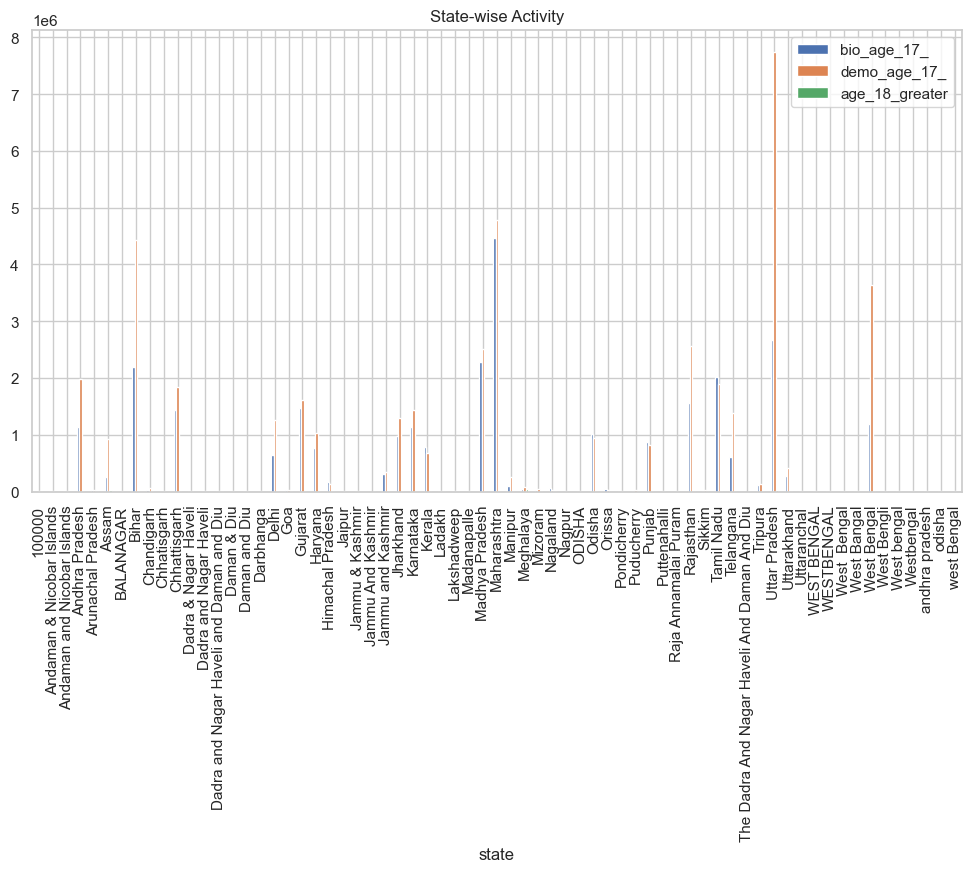

In [ ]:
#REGIONAL ANALYSIS#
state_data = df.groupby('state').sum(numeric_only=True)

state_data[['bio_age_17_', 'demo_age_17_', 'age_18_greater']].plot(kind='bar', figsize=(12,6))
plt.title("State-wise Activity")
plt.show()

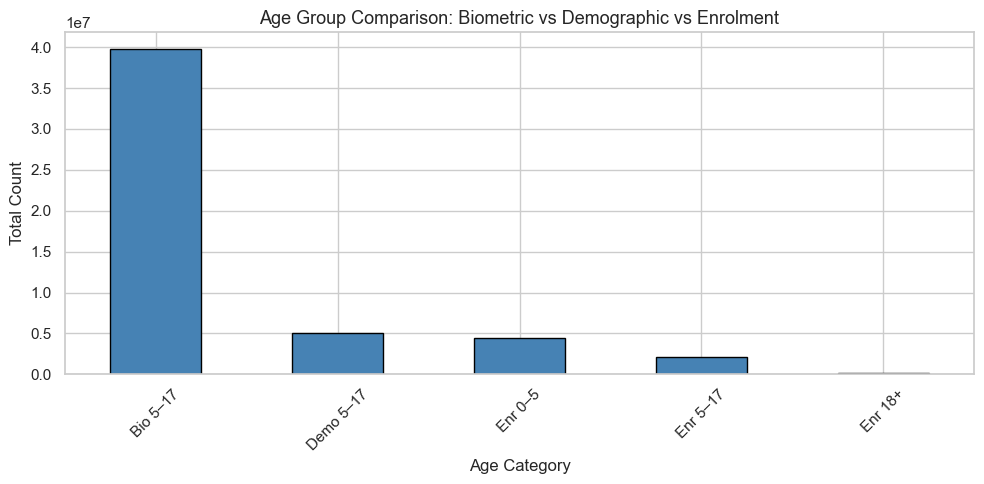

In [ ]:
#AGE BASED ANALYSIS#
import matplotlib.pyplot as plt

# Correct column names post-rename and post-merge
# bio and demo: prefixed | enr: original names retained
age_cols = [
    'bio_age_5_17',         # biometric, 5–17
    'bio_age_18_greater',   # biometric, 18+   (FIXED)
    'demo_age_5_17',        # demographic, 5–17
    'demo_age_18_greater',  # demographic, 18+ (FIXED)
    'age_0_5',              # enrolment, 0–5
    'age_5_17',             # enrolment, 5–17  (FIXED: was 'enr_age_5_17')
    'age_18_greater'        # enrolment, 18+
]

# Safety check — report any columns not found in df
missing_cols = [col for col in age_cols if col not in df.columns]
if missing_cols:
    print(f"WARNING: Missing columns will be skipped: {missing_cols}")

# Use only available columns
valid_age_cols = [col for col in age_cols if col in df.columns]
age_analysis = df[valid_age_cols].sum()

# Readable labels for x-axis
label_map = {
    'bio_age_5_17':        'Bio 5–17',
    'bio_age_18_greater':  'Bio 18+',
    'demo_age_5_17':       'Demo 5–17',
    'demo_age_18_greater': 'Demo 18+',
    'age_0_5':             'Enr 0–5',
    'age_5_17':            'Enr 5–17',
    'age_18_greater':      'Enr 18+'
}
age_analysis.index = [label_map.get(c, c) for c in age_analysis.index]

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
age_analysis.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')

ax.set_title("Age Group Comparison: Biometric vs Demographic vs Enrolment", fontsize=13)
ax.set_xlabel("Age Category")
ax.set_ylabel("Total Count")
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

df['date'] dtype BEFORE fix: object
df['date'] dtype AFTER fix : datetime64[ns]
Unparseable date rows (NaT): 0

Monthly aggregation shape : (9, 9)
Date range                 : 2025-03-01 00:00:00 → 2025-12-01 00:00:00
Date dtype in monthly      : datetime64[ns]

WARNING — Columns missing from monthly, skipped: {'bio_age_18_greater', 'demo_age_18_greater'}

Columns being plotted: ['Biometric 5–17', 'Demographic 5–17']


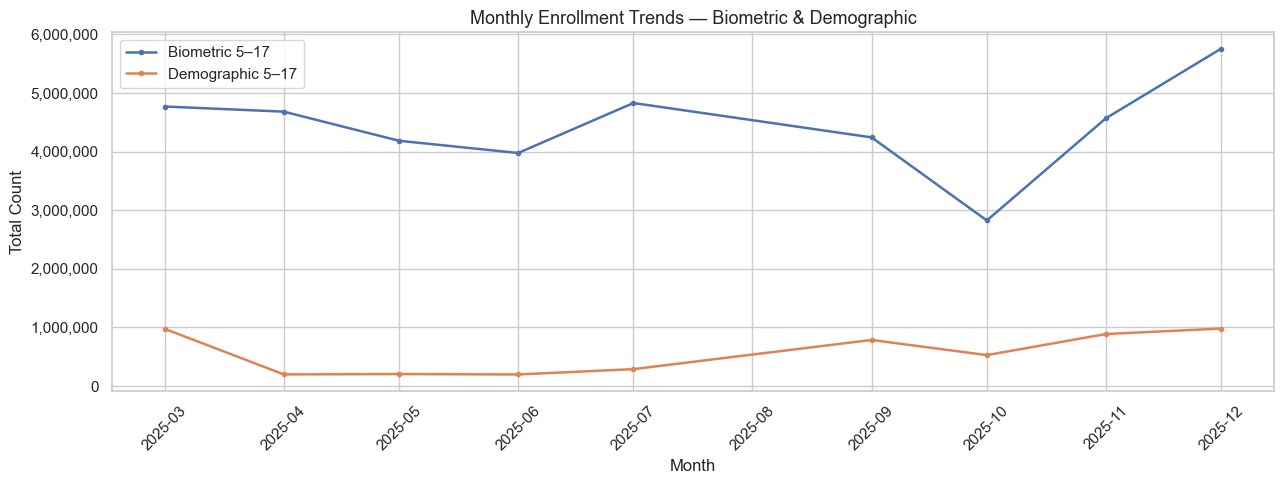


Month-over-Month Growth Rate (%) — Last 6 Months:

  Biometric 5–17:
      date  bio_age_5_17_mom_pct
2025-06-01                 -4.99
2025-07-01                 21.44
2025-09-01                -12.14
2025-10-01                -33.42
2025-11-01                 61.74
2025-12-01                 26.01

  Demographic 5–17:
      date  demo_age_5_17_mom_pct
2025-06-01                  -3.48
2025-07-01                  45.85
2025-09-01                 172.57
2025-10-01                 -32.87
2025-11-01                  68.15
2025-12-01                  10.54



In [ ]:
# TIME SERIES ANALYSIS #
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ════════════════════════════════════════════════════════════════
# STEP A — Guarantee df['date'] is datetime BEFORE any groupby
# This is the actual fix for the AttributeError
# ════════════════════════════════════════════════════════════════

print("df['date'] dtype BEFORE fix:", df['date'].dtype)

# Force conversion — safe to run even if already datetime
df['date'] = pd.to_datetime(df['date'], dayfirst=True, errors='coerce')

# Report how many dates failed to parse (NaT = failed conversion)
nat_count = df['date'].isna().sum()
print(f"df['date'] dtype AFTER fix : {df['date'].dtype}")
print(f"Unparseable date rows (NaT): {nat_count}")

# Drop rows where date could not be parsed — cannot group on NaT
if nat_count > 0:
    df = df.dropna(subset=['date'])
    print(f"Rows remaining after NaT drop: {len(df)}")

# ════════════════════════════════════════════════════════════════
# STEP B — Monthly Aggregation
# Now .dt accessor is safe to use
# ════════════════════════════════════════════════════════════════

monthly = (
    df.groupby(df['date'].dt.to_period('M'))   # group by year-month
      .sum(numeric_only=True)                   # sum all numeric columns
)

# Convert PeriodIndex → DatetimeIndex (required for plotting)
# Must be done on INDEX, not on column — this was the previous bug
monthly.index = monthly.index.to_timestamp()
monthly = monthly.reset_index()                # 'date' column is now datetime64

print(f"\nMonthly aggregation shape : {monthly.shape}")
print(f"Date range                 : {monthly['date'].min()} → {monthly['date'].max()}")
print(f"Date dtype in monthly      : {monthly['date'].dtype}")

# ════════════════════════════════════════════════════════════════
# STEP C — Define columns to plot
# ════════════════════════════════════════════════════════════════

ts_cols = {
    'bio_age_18_greater':  'Biometric 18+',
    'demo_age_18_greater': 'Demographic 18+',
    'bio_age_5_17':        'Biometric 5–17',
    'demo_age_5_17':       'Demographic 5–17'
}

# Keep only columns that exist in monthly
valid_cols = {k: v for k, v in ts_cols.items() if k in monthly.columns}
missing    = set(ts_cols) - set(valid_cols)

if missing:
    print(f"\nWARNING — Columns missing from monthly, skipped: {missing}")

if not valid_cols:
    raise ValueError(
        "No plottable columns found. "
        "Verify rename steps in merge cell produced: "
        + str(list(ts_cols.keys()))
    )

print(f"\nColumns being plotted: {list(valid_cols.values())}")

# ════════════════════════════════════════════════════════════════
# STEP D — Plot Monthly Trends
# ════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(13, 5))

for col, label in valid_cols.items():
    ax.plot(
        monthly['date'], monthly[col],
        marker='o', linewidth=1.8, markersize=3, label=label
    )

# Annotate spikes: points beyond mean + 2σ
for col, label in valid_cols.items():
    mean      = monthly[col].mean()
    std       = monthly[col].std()
    threshold = mean + 2 * std
    spikes    = monthly[monthly[col] > threshold]

    for _, row in spikes.iterrows():
        ax.annotate(
            f"Spike\n{row['date'].strftime('%b %Y')}",
            xy=(row['date'], row[col]),
            xytext=(10, 10), textcoords='offset points',
            fontsize=7, color='red',
            arrowprops=dict(arrowstyle='->', color='red', lw=0.8)
        )

ax.set_title("Monthly Enrollment Trends — Biometric & Demographic", fontsize=13)
ax.set_xlabel("Month")
ax.set_ylabel("Total Count")
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}')
)
ax.legend(loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ════════════════════════════════════════════════════════════════
# STEP E — Month-over-Month Growth Rate
# Formula: MoM% = ((x_t - x_{t-1}) / x_{t-1}) * 100
# ════════════════════════════════════════════════════════════════

print("\nMonth-over-Month Growth Rate (%) — Last 6 Months:\n")

mom_df = monthly[['date']].copy()

for col, label in valid_cols.items():
    mom_df[f'{col}_mom_pct'] = (
        monthly[col]
        .pct_change()
        .replace([np.inf, -np.inf], np.nan)   # guard: division by zero
        .mul(100)
        .round(2)
    )
    print(f"  {label}:")
    print(
        mom_df[['date', f'{col}_mom_pct']]
        .dropna()
        .tail(6)
        .to_string(index=False)
    )
    print()

df['date'] dtype : datetime64[ns]
Total rows       : 2947681

Columns used for total_updates : ['bio_age_5_17', 'demo_age_5_17', 'age_0_5', 'age_5_17', 'age_18_greater']
WARNING — Skipped missing columns: {'bio_age_18_greater', 'demo_age_18_greater'}

total_updates — sample:
count    2947681.00
mean          17.48
std           89.65
min            0.00
25%            1.00
50%            4.00
75%           12.00
max        10288.00
Name: total_updates, dtype: float64

Distribution Summary:
  Mean             : 17
  Std Dev          : 90
  Upper threshold  : 286  (mean + 3σ)
  Lower threshold  : -251  (mean - 3σ)

Total anomalous records : 24813
As % of dataset         : 0.84%

Top 10 Anomalous Records:

      date         state         district  total_updates    z_score
2025-07-01 Uttar Pradesh        Moradabad        10288.0 114.566102
2025-04-01 Uttar Pradesh        Moradabad         9701.0 108.018206
2025-04-01         Delhi North East Delhi         9611.0 107.014270
2025-04-01     

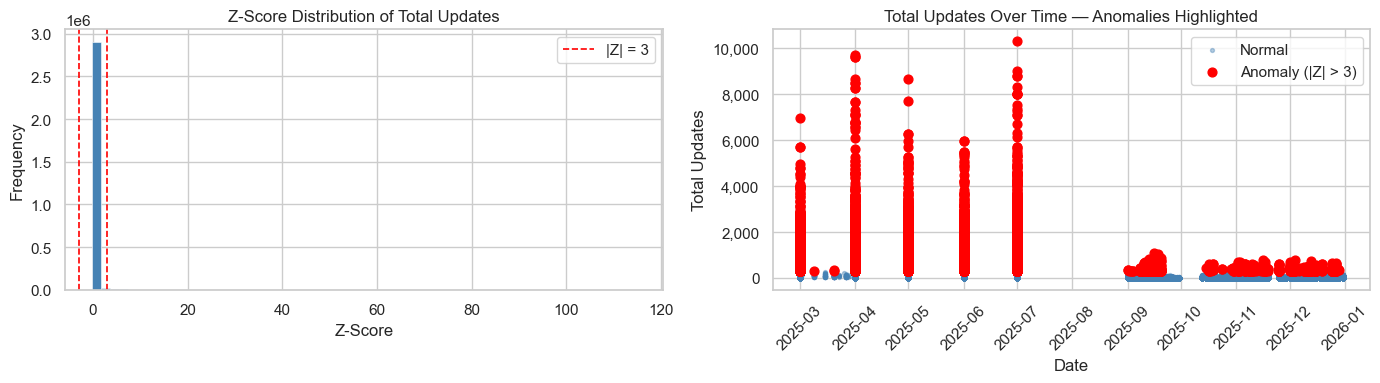

In [ ]:
# TIME SERIES ANOMALY DETECTION #
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ════════════════════════════════════════════════════════════════
# STEP A — Guarantee df['date'] is datetime (same fix as Step 6)
# ════════════════════════════════════════════════════════════════

df['date'] = pd.to_datetime(df['date'], dayfirst=True, errors='coerce')
df = df.dropna(subset=['date'])

print(f"df['date'] dtype : {df['date'].dtype}")
print(f"Total rows       : {len(df)}")

# ════════════════════════════════════════════════════════════════
# STEP B — Build total_updates from all valid age columns
# ════════════════════════════════════════════════════════════════

# All possible age columns after rename + merge
candidate_cols = [
    'bio_age_5_17',
    'bio_age_18_greater',
    'demo_age_5_17',
    'demo_age_18_greater',
    'age_0_5',
    'age_5_17',
    'age_18_greater'
]

# Keep only columns that actually exist in df
update_cols = [c for c in candidate_cols if c in df.columns]
missing_cols = set(candidate_cols) - set(update_cols)

print(f"\nColumns used for total_updates : {update_cols}")
if missing_cols:
    print(f"WARNING — Skipped missing columns: {missing_cols}")

if not update_cols:
    raise ValueError(
        "No age columns found. "
        "Verify rename steps produced: " + str(candidate_cols)
    )

# Row-wise sum across all age columns
df['total_updates'] = df[update_cols].sum(axis=1)

print(f"\ntotal_updates — sample:\n{df['total_updates'].describe().round(2)}")

# ════════════════════════════════════════════════════════════════
# STEP C — Z-Score Calculation
# Formula: Z = (x - μ) / σ
# |Z| > 3 → ~0.3% tail → strong anomaly signal
# ════════════════════════════════════════════════════════════════

mean_val = df['total_updates'].mean()
std_val  = df['total_updates'].std()

# Guard: if std is 0 (all values identical), z-score is undefined
if std_val == 0:
    raise ValueError(
        "Standard deviation of total_updates is 0. "
        "All rows have identical values — cannot compute Z-score."
    )

df['z_score'] = (df['total_updates'] - mean_val) / std_val

print(f"\nDistribution Summary:")
print(f"  Mean             : {mean_val:,.0f}")
print(f"  Std Dev          : {std_val:,.0f}")
print(f"  Upper threshold  : {mean_val + 3 * std_val:,.0f}  (mean + 3σ)")
print(f"  Lower threshold  : {mean_val - 3 * std_val:,.0f}  (mean - 3σ)")

# ════════════════════════════════════════════════════════════════
# STEP D — Flag Anomalies
# ════════════════════════════════════════════════════════════════

anomalies = df[df['z_score'].abs() > 3].copy()
anomalies = anomalies.sort_values('z_score', ascending=False)

print(f"\nTotal anomalous records : {len(anomalies)}")
print(f"As % of dataset         : {len(anomalies) / len(df) * 100:.2f}%")

# Display key columns only
display_cols = ['date', 'state', 'district', 'total_updates', 'z_score']
display_cols = [c for c in display_cols if c in anomalies.columns]

print(f"\nTop 10 Anomalous Records:\n")
print(anomalies[display_cols].head(10).to_string(index=False))

# ════════════════════════════════════════════════════════════════
# STEP E — Visualize
# ════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Panel A — Z-Score Distribution
axes[0].hist(
    df['z_score'].dropna(), bins=60,
    color='steelblue', edgecolor='white', linewidth=0.4
)
axes[0].axvline( 3, color='red', linestyle='--', linewidth=1.2, label='|Z| = 3')
axes[0].axvline(-3, color='red', linestyle='--', linewidth=1.2)
axes[0].set_title("Z-Score Distribution of Total Updates")
axes[0].set_xlabel("Z-Score")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# Panel B — Anomalies over Time
axes[1].scatter(
    df['date'], df['total_updates'],
    color='steelblue', s=8, alpha=0.4, label='Normal'
)
axes[1].scatter(
    anomalies['date'], anomalies['total_updates'],
    color='red', s=40, zorder=5, label='Anomaly (|Z| > 3)'
)
axes[1].set_title("Total Updates Over Time — Anomalies Highlighted")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Total Updates")
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}')
)
axes[1].legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Unique districts : 1029
total_updates dtype: float64

Volatility Table — Top 10 by Std Dev:

                  mean_updates  std_updates  record_count    cv
district                                                       
North East Delhi        254.79       985.00           587  3.87
Dinajpur Uttar         1061.00       850.60            11  0.80
Barwani                 132.05       650.82          1106  4.93
West Delhi              102.62       538.78          1405  5.25
Pilibhit                129.13       516.61          1142  4.00
Sidhi                    92.19       491.21          1198  5.33
Morena                  112.71       464.82          1482  4.12
Nuh                     753.00       461.03             2  0.61
Singrauli                79.94       457.76          1419  5.73
Rampur                  109.98       455.80          1260  4.14


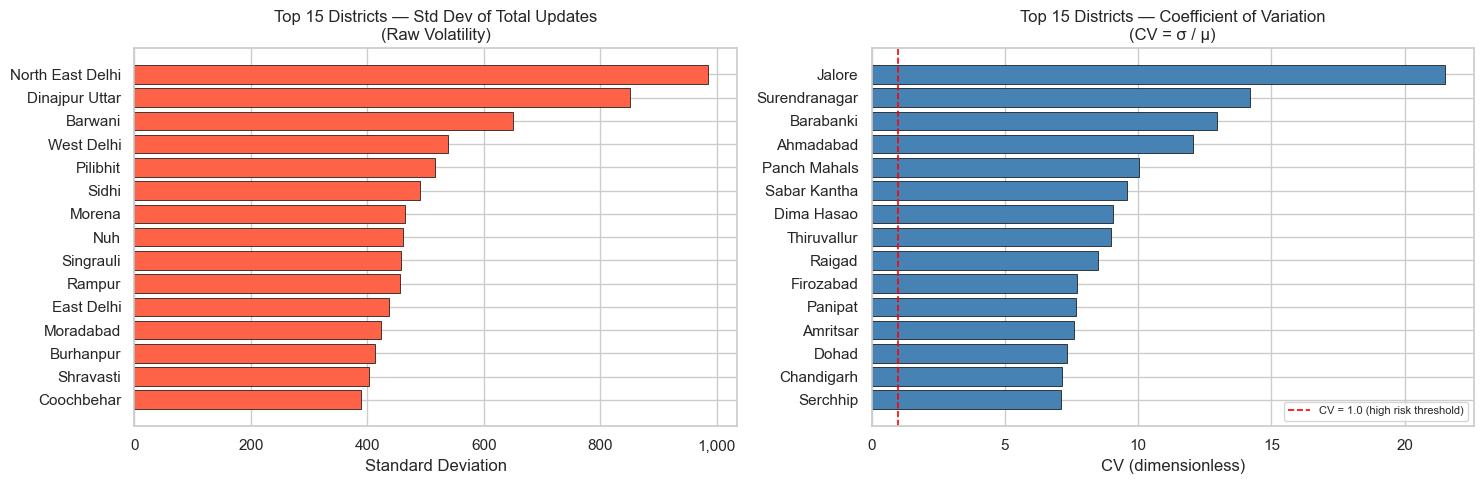


High-Risk Districts (CV > 1.0) : 960
Interpretation : std deviation exceeds the mean — highly erratic

                  mean_updates  std_updates    cv  record_count
district                                                       
North East Delhi        254.79       985.00  3.87           587
Barwani                 132.05       650.82  4.93          1106
West Delhi              102.62       538.78  5.25          1405
Pilibhit                129.13       516.61  4.00          1142
Sidhi                    92.19       491.21  5.33          1198
Morena                  112.71       464.82  4.12          1482
Singrauli                79.94       457.76  5.73          1419
Rampur                  109.98       455.80  4.14          1260
East Delhi              105.14       437.46  4.16          1151
Moradabad                66.66       424.19  6.36          2340


In [ ]:
# TIME SERIES VOLATILITY ANALYSIS #

# ════════════════════════════════════════════════════════════════
# STEP A — Verify total_updates exists (depends on Step 7)
# ════════════════════════════════════════════════════════════════

if 'total_updates' not in df.columns:
    raise ValueError(
        "total_updates column not found. "
        "Run Step 7 (Anomaly Detection) first."
    )

if 'district' not in df.columns:
    raise ValueError(
        "district column not found. "
        "Verify the merge in the data preparation step."
    )

print(f"Unique districts : {df['district'].nunique()}")
print(f"total_updates dtype: {df['total_updates'].dtype}")

# ════════════════════════════════════════════════════════════════
# STEP B — Compute Volatility Metrics per District
# ════════════════════════════════════════════════════════════════

volatility = (
    df.groupby('district')['total_updates']
      .agg(
          mean_updates='mean',     # average monthly activity
          std_updates='std',       # raw volatility
          record_count='count'     # number of data points
      )
      .dropna(subset=['std_updates'])   # drop districts with only 1 record
)

# Coefficient of Variation = σ / μ
# Scale-independent — avoids bias toward high-volume districts
# CV > 1.0 means std exceeds mean → highly erratic behavior
volatility['cv'] = volatility['std_updates'] / volatility['mean_updates']

volatility = volatility.sort_values('std_updates', ascending=False).round(2)

print(f"\nVolatility Table — Top 10 by Std Dev:\n")
print(volatility.head(10).to_string())

# ════════════════════════════════════════════════════════════════
# STEP C — Visualize: Std Dev + CV side by side
# ════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Panel A — Raw Standard Deviation (Top 15)
top15_std = volatility.head(15).reset_index()

axes[0].barh(
    top15_std['district'], top15_std['std_updates'],
    color='tomato', edgecolor='black', linewidth=0.5
)
axes[0].set_title("Top 15 Districts — Std Dev of Total Updates\n(Raw Volatility)")
axes[0].set_xlabel("Standard Deviation")
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}')
)
axes[0].invert_yaxis()

# Panel B — Coefficient of Variation (Top 15)
# Tells you which districts are erratic RELATIVE to their own size
top15_cv = (
    volatility.sort_values('cv', ascending=False)
              .head(15)
              .reset_index()
)

axes[1].barh(
    top15_cv['district'], top15_cv['cv'],
    color='steelblue', edgecolor='black', linewidth=0.5
)
axes[1].axvline(
    1.0, color='red', linestyle='--',
    linewidth=1.2, label='CV = 1.0 (high risk threshold)'
)
axes[1].set_title("Top 15 Districts — Coefficient of Variation\n(CV = σ / μ)")
axes[1].set_xlabel("CV (dimensionless)")
axes[1].invert_yaxis()
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

# ════════════════════════════════════════════════════════════════
# STEP D — Flag High-Risk Districts (CV > 1.0)
# ════════════════════════════════════════════════════════════════

high_risk = volatility[volatility['cv'] > 1.0].copy()

print(f"\nHigh-Risk Districts (CV > 1.0) : {len(high_risk)}")
print(f"Interpretation : std deviation exceeds the mean — highly erratic\n")
print(
    high_risk[['mean_updates', 'std_updates', 'cv', 'record_count']]
    .head(10)
    .to_string()
)